# Previsão de Churn — Cell2Cell (Módulo de Previsão, Dia N)

Sistema inteligente de retenção: **prever → explicar → agir**.
Este notebook cobre a etapa de previsão: análise exploratória, tratamento
dos dados, baseline (Regressão Logística), modelo principal (XGBoost),
validação cruzada e ajuste do ponto de decisão para priorizar a detecção
de cancelamentos.

**Como usar no Colab:** rode a célula abaixo e faça upload do
`cell2celltrain.csv` quando solicitado (ou ajuste `CAMINHO_CSV`).

In [1]:
from pathlib import Path

CAMINHO_CSV = "cell2celltrain.csv"

if not Path(CAMINHO_CSV).exists():
    try:
        from google.colab import files  # type: ignore

        enviado = files.upload()
        CAMINHO_CSV = next(iter(enviado))
    except ImportError:
        CAMINHO_CSV = "../data/raw/cell2celltrain.csv"  # execucao local
print("Usando:", CAMINHO_CSV)

Usando: ../data/raw/cell2celltrain.csv


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42

df_raw = pd.read_csv(CAMINHO_CSV)
print(f"{df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
df_raw.head(3)

51,047 linhas x 58 colunas


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes


## 1. Análise exploratória

### 1.1 Balanceamento do alvo

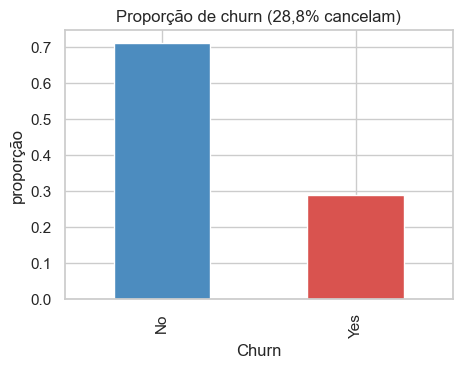

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
df_raw["Churn"].value_counts(normalize=True).plot.bar(ax=ax, color=["#4c8cbf", "#d9534f"])
ax.set_title("Proporção de churn (28,8% cancelam)")
ax.set_ylabel("proporção")
plt.show()

### 1.2 Valores faltantes — o problema real está disfarçado

O NaN explícito é pequeno (máx. 1,78%), mas três colunas usam a *string*
`"Unknown"` e as idades usam **zero** para "não informado":

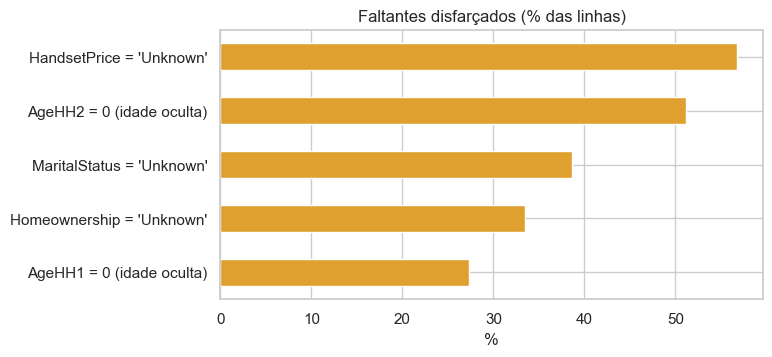

In [4]:
disfarcados = pd.Series({
    "HandsetPrice = 'Unknown'": (df_raw["HandsetPrice"] == "Unknown").mean(),
    "MaritalStatus = 'Unknown'": (df_raw["MaritalStatus"] == "Unknown").mean(),
    "Homeownership = 'Unknown'": (df_raw["Homeownership"] == "Unknown").mean(),
    "AgeHH1 = 0 (idade oculta)": (df_raw["AgeHH1"] == 0).mean(),
    "AgeHH2 = 0 (idade oculta)": (df_raw["AgeHH2"] == 0).mean(),
})
fig, ax = plt.subplots(figsize=(7, 3.5))
(disfarcados * 100).sort_values().plot.barh(ax=ax, color="#e0a030")
ax.set_title("Faltantes disfarçados (% das linhas)")
ax.set_xlabel("%")
plt.show()

### 1.3 Sinal de negócio: idade do aparelho e tempo de contrato

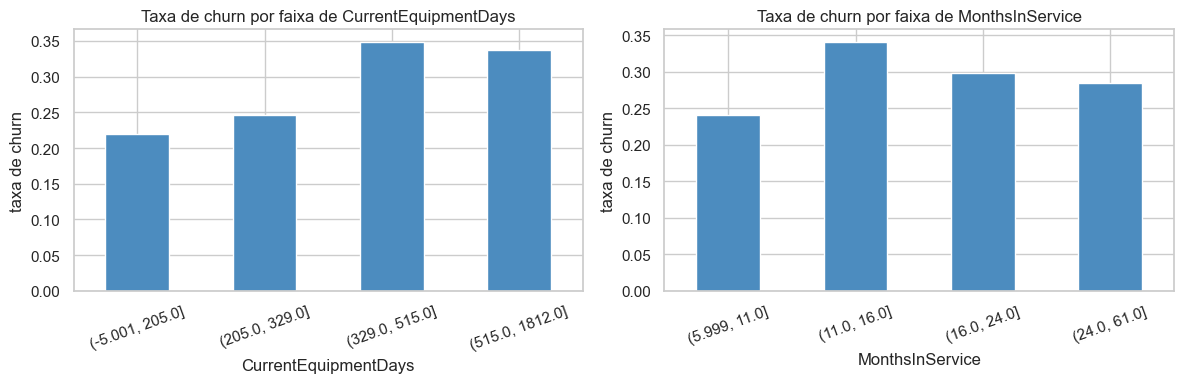

In [5]:
df_eda = df_raw.assign(churn_bin=(df_raw["Churn"] == "Yes").astype(int))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["CurrentEquipmentDays", "MonthsInService"]):
    faixas = pd.qcut(pd.to_numeric(df_eda[col], errors="coerce"), 4, duplicates="drop")
    df_eda.groupby(faixas, observed=True)["churn_bin"].mean().plot.bar(ax=ax, color="#4c8cbf")
    ax.set_title(f"Taxa de churn por faixa de {col}")
    ax.set_ylabel("taxa de churn")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Clientes com aparelho velho (>330 dias) cancelam ~35% contra 22% dos
aparelhos novos — candidato forte a fator de risco. O churn tem pico
entre 11 e 16 meses de contrato (fim de fidelização).

## 2. Tratamento dos dados

Resumo das decisões (diagnóstico completo em
`reports/02_diagnostico_tratamento.md` do repositório):

| Problema | Solução |
|---|---|
| "Unknown" em massa | Flags `*Known` + mediana / categoria própria |
| Idade = 0 | Tratada como desconhecida (flag + mediana) |
| Dias de aparelho negativos | NaN → mediana (fisicamente impossível) |
| ServiceArea com 747 categorias | Frequency encoding (sem usar o alvo) |
| CreditRating | Ordinal 1–7 |
| 15 colunas Yes/No | Binárias 1/0 |

In [6]:
COLS_YES_NO = [
    "ChildrenInHH", "HandsetRefurbished", "HandsetWebCapable", "TruckOwner",
    "RVOwner", "BuysViaMailOrder", "RespondsToMailOffers", "OptOutMailings",
    "NonUSTravel", "OwnsComputer", "HasCreditCard", "NewCellphoneUser",
    "NotNewCellphoneUser", "OwnsMotorcycle", "MadeCallToRetentionTeam",
]
COLS_FATURA = [
    "MonthlyRevenue", "MonthlyMinutes", "TotalRecurringCharge",
    "DirectorAssistedCalls", "OverageMinutes", "RoamingCalls",
]
ORDEM_CREDITO = {
    "1-Highest": 1, "2-High": 2, "3-Good": 3, "4-Medium": 4,
    "5-Low": 5, "6-VeryLow": 6, "7-Lowest": 7,
}


def tratar(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Churn"] = (out["Churn"] == "Yes").astype(int)
    for col in COLS_YES_NO:
        out[col] = (out[col] == "Yes").astype(int)

    out["HomeownershipKnown"] = (out["Homeownership"] == "Known").astype(int)
    out = out.drop(columns=["Homeownership"])
    out = pd.concat([out.drop(columns=["MaritalStatus"]),
                     pd.get_dummies(out["MaritalStatus"], prefix="MaritalStatus", dtype=int)],
                    axis=1)

    preco = pd.to_numeric(out["HandsetPrice"].replace("Unknown", np.nan), errors="coerce")
    out["HandsetPriceKnown"] = preco.notna().astype(int)
    out["HandsetPrice"] = preco.fillna(preco.median())

    for col in ["AgeHH1", "AgeHH2"]:
        idade = out[col].replace(0, np.nan)
        out[f"{col}Known"] = idade.notna().astype(int)
        out[col] = idade.fillna(idade.median())

    dias = out["CurrentEquipmentDays"].where(out["CurrentEquipmentDays"] >= 0)
    out["CurrentEquipmentDays"] = dias.fillna(dias.median())

    out["MissingBillingInfo"] = out[COLS_FATURA].isna().all(axis=1).astype(int)
    residuais = COLS_FATURA + ["PercChangeMinutes", "PercChangeRevenues",
                               "Handsets", "HandsetModels"]
    for col in residuais:
        out[col] = out[col].fillna(out[col].median())

    out["CreditRating"] = out["CreditRating"].map(ORDEM_CREDITO).astype(int)
    for col in ["PrizmCode", "Occupation"]:
        out = pd.concat([out.drop(columns=[col]),
                         pd.get_dummies(out[col], prefix=col, dtype=int)], axis=1)

    area = out["ServiceArea"].fillna("DESCONHECIDA")
    out["ServiceAreaFreq"] = area.map(area.value_counts(normalize=True))
    out = out.drop(columns=["ServiceArea"]).set_index("CustomerID")
    return out


df = tratar(df_raw)
assert df.isna().sum().sum() == 0 and len(df) == len(df_raw)
print(f"Tratado: {df.shape[0]:,} x {df.shape[1]} | NaN: 0 | taxa de churn: {df['Churn'].mean():.2%}")

Tratado: 51,047 x 73 | NaN: 0 | taxa de churn: 28.82%


## 3. Modelagem

Split estratificado 80/20. Desbalanceamento tratado **dentro dos modelos**
(`class_weight` / `scale_pos_weight`), sem SMOTE — os pesos deram recall
equivalente sem custo extra.

In [7]:
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

razao = float((y_train == 0).sum() / (y_train == 1).sum())
modelos = {
    "Regressão Logística (baseline)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                   random_state=SEED)),
    ]),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        scale_pos_weight=razao, eval_metric="auc",
        tree_method="hist", n_jobs=-1, random_state=SEED),
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
linhas = []
for nome, modelo in modelos.items():
    res = cross_validate(modelo, X_train, y_train, cv=CV,
                         scoring=["recall", "f1", "roc_auc", "precision"])
    linhas.append({"modelo": nome, **{
        m: f"{res[f'test_{m}'].mean():.3f} ± {res[f'test_{m}'].std():.3f}"
        for m in ["recall", "f1", "roc_auc", "precision"]}})
pd.DataFrame(linhas)

,modelo,recall,f1,roc_auc,precision
0,Regressão Logística (baseline),0.565 ± 0.013,0.442 ± 0.009,0.617 ± 0.009,0.363 ± 0.008
1,XGBoost,0.565 ± 0.010,0.482 ± 0.008,0.678 ± 0.008,0.420 ± 0.009


## 4. Ajuste do ponto de decisão (priorizar detecção)

Critério: maximizar **F2** (recall pesa 2× a precisão) nas predições
*out-of-fold* do treino — o teste não participa da escolha. Lógica de
negócio: um falso positivo custa uma promoção; um falso negativo custa
o cliente.

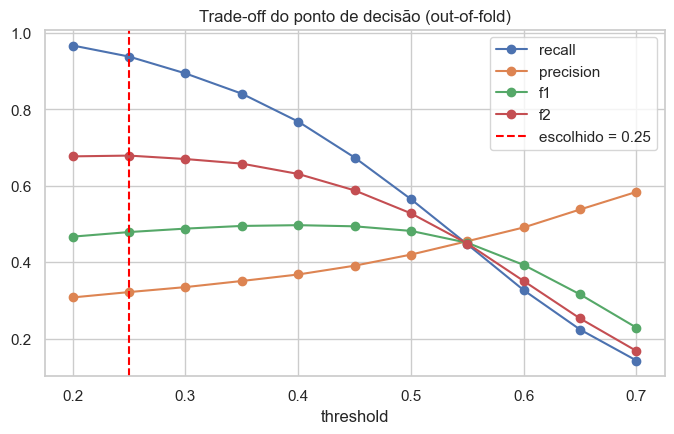

,threshold,recall,precision,f1,f2
0,0.20,0.967,0.308,0.467,0.677
1,0.25,0.938,0.322,0.479,0.679
2,0.30,0.894,0.335,0.488,0.670
3,0.35,0.841,0.351,0.495,0.658
4,0.40,0.768,0.368,0.497,0.631
5,0.45,0.674,0.391,0.494,0.588
6,0.50,0.565,0.420,0.482,0.528
7,0.55,0.447,0.455,0.451,0.449
8,0.60,0.327,0.491,0.393,0.351
9,0.65,0.224,0.538,0.316,0.253


In [8]:
proba_oof = cross_val_predict(modelos["XGBoost"], X_train, y_train,
                              cv=CV, method="predict_proba")[:, 1]
candidatos = np.arange(0.20, 0.71, 0.05)
curva = pd.DataFrame([{
    "threshold": round(float(t), 2),
    "recall": recall_score(y_train, proba_oof >= t),
    "precision": precision_score(y_train, proba_oof >= t),
    "f1": f1_score(y_train, proba_oof >= t),
    "f2": fbeta_score(y_train, proba_oof >= t, beta=2),
} for t in candidatos]).round(3)
THRESHOLD = float(curva.loc[curva["f2"].idxmax(), "threshold"])

fig, ax = plt.subplots(figsize=(8, 4.5))
for metrica in ["recall", "precision", "f1", "f2"]:
    ax.plot(curva["threshold"], curva[metrica], marker="o", label=metrica)
ax.axvline(THRESHOLD, color="red", ls="--", label=f"escolhido = {THRESHOLD}")
ax.set_xlabel("threshold")
ax.set_title("Trade-off do ponto de decisão (out-of-fold)")
ax.legend()
plt.show()
curva

## 5. Avaliação final no conjunto de teste

In [9]:
probas = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    probas[nome] = modelo.predict_proba(X_test)[:, 1]

resultados = []
for nome, thr in [("Regressão Logística (baseline)", 0.5),
                  ("XGBoost", 0.5), ("XGBoost", THRESHOLD)]:
    pred = (probas[nome] >= thr).astype(int)
    resultados.append({
        "modelo": nome, "threshold": thr,
        "recall": recall_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "auc_roc": roc_auc_score(y_test, probas[nome]),
    })
pd.DataFrame(resultados).round(3)

,modelo,threshold,recall,precision,f1,auc_roc
0,Regressão Logística (baseline),0.50,0.577,0.364,0.447,0.615
1,XGBoost,0.50,0.575,0.409,0.478,0.677
2,XGBoost,0.25,0.944,0.318,0.475,0.677


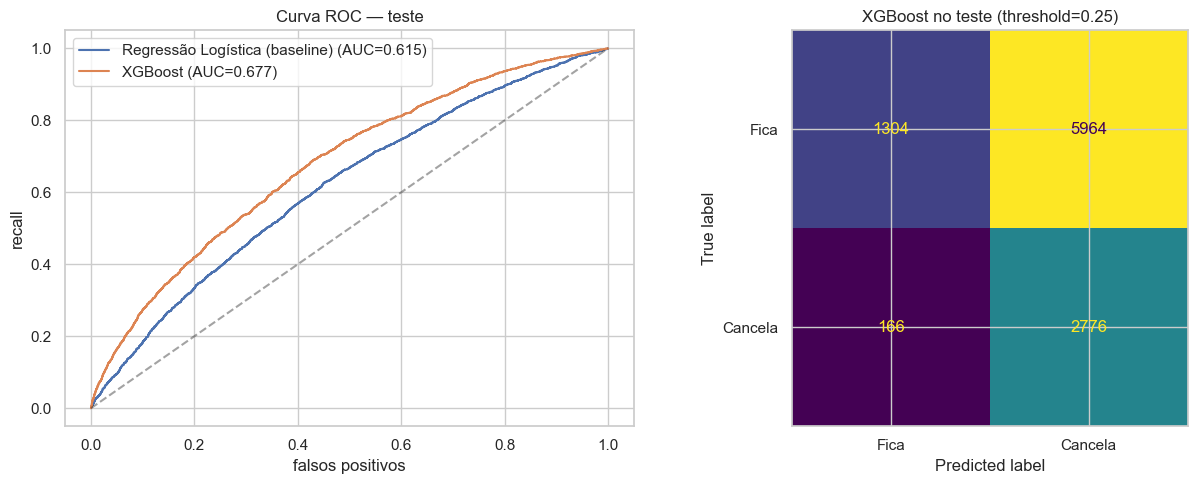

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nome, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{nome} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("Curva ROC — teste")
axes[0].set_xlabel("falsos positivos")
axes[0].set_ylabel("recall")
axes[0].legend()

pred = (probas["XGBoost"] >= THRESHOLD).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Fica", "Cancela"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"XGBoost no teste (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 6. Variáveis mais importantes e ranking de risco

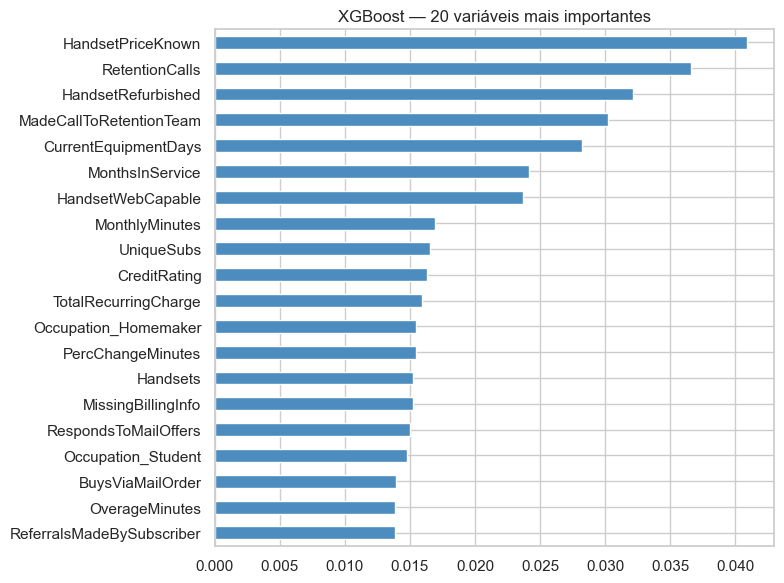

,prob_churn,churn_real
CustomerID,,
3334666,0.9560,0
3143290,0.9308,1
3253046,0.9277,1
3191090,0.9238,1
3272650,0.9228,0
3217586,0.9179,1
3274730,0.9152,1
3360206,0.9143,1
3010870,0.9130,1


In [11]:
importancia = pd.Series(modelos["XGBoost"].feature_importances_, index=X.columns)
fig, ax = plt.subplots(figsize=(8, 6))
importancia.sort_values().tail(20).plot.barh(ax=ax, color="#4c8cbf")
ax.set_title("XGBoost — 20 variáveis mais importantes")
plt.tight_layout()
plt.show()

ranking = (pd.DataFrame({"prob_churn": probas["XGBoost"].round(4),
                         "churn_real": y_test.values}, index=X_test.index)
           .sort_values("prob_churn", ascending=False))
ranking.head(10)

## Conclusões

- **XGBoost: AUC 0,68** no teste, acima do baseline (0,62) e no patamar dos
  benchmarks publicados para o Cell2Cell (0,65–0,70) — churn de telecom tem
  muito fator externo que os dados não capturam.
- Com o **threshold 0,25** (máximo F2 out-of-fold), o sistema detecta
  **~94% dos clientes que cancelariam**, ao custo de ~2 falsos positivos por
  acerto — aceitável porque reter custa menos que adquirir.
- O topo do ranking concentra probabilidades >0,9: é onde a equipe de
  retenção atua primeiro.

**Próxima etapa (Dia H):** explicações SHAP individuais, agente de
recomendação com feedback simulado e dashboard integrado.